# 01 - Dataset Inspection

This notebook inspects the raw NASA Battery Aging `.mat` files before preprocessing or modeling.

Main checks:

- locate the raw dataset;
- list available battery files;
- inspect one battery file structure;
- count `charge`, `discharge`, and `impedance` operations;
- confirm fields available for each operation type;
- plot discharge capacity fade;
- plot voltage, current, and temperature for one discharge operation.


## Setup

If imports fail, install dependencies from the repository root with `pip install -r requirements.txt`.

In [2]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

## Locate Raw Data

The default raw dataset path is `/home/aymen/data/nasa-battery`. Override it with `NASA_BATTERY_DATA` if needed.

In [3]:
DATA_ROOT = Path(os.environ.get("NASA_BATTERY_DATA", "/home/aymen/data/nasa-battery"))

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Raw dataset folder not found: {DATA_ROOT}")

mat_files = sorted(DATA_ROOT.glob("**/B*.mat"))
readme_files = sorted(DATA_ROOT.glob("**/README*"))

print(f"Dataset root: {DATA_ROOT}")
print(f"Battery .mat files: {len(mat_files)}")
print(f"README files: {len(readme_files)}")

pd.DataFrame({
    "battery_id": [path.stem for path in mat_files],
    "folder": [path.parent.name for path in mat_files],
    "path": [str(path) for path in mat_files],
}).head(20)

Dataset root: /home/aymen/data/nasa-battery
Battery .mat files: 38
README files: 10


,battery_id,folder,path
0,B0005,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0005.mat
1,B0006,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0006.mat
2,B0007,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0007.mat
3,B0018,1. BatteryAgingARC-FY08Q4,/home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0018.mat
4,B0025,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0025.mat
5,B0026,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0026.mat
6,B0027,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0027.mat
7,B0028,2. BatteryAgingARC_25_26_27_28_P1,/home/aymen/data/nasa-battery/2. BatteryAgingARC_25_26_27_28_P1/B0028.mat
8,B0025,3. BatteryAgingARC_25-44,/home/aymen/data/nasa-battery/3. BatteryAgingARC_25-44/B0025.mat
9,B0026,3. BatteryAgingARC_25-44,/home/aymen/data/nasa-battery/3. BatteryAgingARC_25-44/B0026.mat


## Load One Battery

`B0005` is one of the common files in the first NASA Battery Aging subset.

In [4]:
sample_path = DATA_ROOT / "1. BatteryAgingARC-FY08Q4" / "B0005.mat"
if not sample_path.exists():
    sample_path = mat_files[0]

def load_battery_mat(path: Path):
    raw = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    battery_id = path.stem
    if battery_id not in raw:
        visible_keys = [key for key in raw.keys() if not key.startswith("__")]
        raise KeyError(f"Expected key {battery_id!r}; available keys: {visible_keys}")
    return raw[battery_id]

battery = load_battery_mat(sample_path)
cycles = np.atleast_1d(battery.cycle)

print(f"Loaded: {sample_path}")
print(f"Top-level cycle entries: {len(cycles)}")

Loaded: /home/aymen/data/nasa-battery/1. BatteryAgingARC-FY08Q4/B0005.mat
Top-level cycle entries: 616


A top-level `cycle` entry is an operation entry. It can be `charge`, `discharge`, or `impedance`. For RUL work, discharge operations are the first useful anchor because they contain measured `Capacity`.

In [5]:
def public_mat_fields(obj):
    if hasattr(obj, "_fieldnames"):
        return list(obj._fieldnames)
    return [name for name in dir(obj) if not name.startswith("_")]

first_cycle = cycles[0]

print("Top-level cycle fields:")
print(public_mat_fields(first_cycle))
print()
print("First cycle type:", first_cycle.type)
print("First cycle ambient temperature:", first_cycle.ambient_temperature)
print()
print("First cycle data fields:")
print(public_mat_fields(first_cycle.data))

Top-level cycle fields:
['type', 'ambient_temperature', 'time', 'data']

First cycle type: charge
First cycle ambient temperature: 24

First cycle data fields:
['Voltage_measured', 'Current_measured', 'Temperature_measured', 'Current_charge', 'Voltage_charge', 'Time']


## Operation Counts and Fields

impedance    278
charge       170
discharge    168
Name: count, dtype: int64

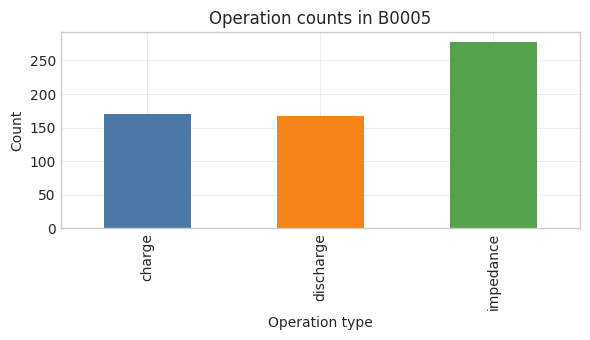

In [6]:
cycle_type_counts = pd.Series([cycle.type for cycle in cycles]).value_counts()
display(cycle_type_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
cycle_type_counts.sort_index().plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title(f"Operation counts in {sample_path.stem}")
ax.set_xlabel("Operation type")
ax.set_ylabel("Count")
plt.tight_layout()

In [7]:
rows = []
for operation_type in sorted(set(cycle.type for cycle in cycles)):
    cycle = next(c for c in cycles if c.type == operation_type)
    rows.append({
        "operation_type": operation_type,
        "top_level_fields": public_mat_fields(cycle),
        "data_fields": public_mat_fields(cycle.data),
    })

pd.DataFrame(rows)

,operation_type,top_level_fields,data_fields
0,charge,"[type, ambient_temperature, time, data]","[Voltage_measured, Current_measured, Temperature_measured, Current_charge, Voltage_charge, Time]"
1,discharge,"[type, ambient_temperature, time, data]","[Voltage_measured, Current_measured, Temperature_measured, Current_load, Voltage_load, Time, Capacity]"
2,impedance,"[type, ambient_temperature, time, data]","[Sense_current, Battery_current, Current_ratio, Battery_impedance, Rectified_Impedance, Re, Rct]"


## Discharge Summary

This is only an inspection table, not final preprocessing. It makes capacity fade and signal ranges easy to inspect.

In [8]:
def to_1d_array(value):
    return np.asarray(value).reshape(-1)

def optional_scalar(data, field_name):
    if not hasattr(data, field_name):
        return np.nan
    arr = np.asarray(getattr(data, field_name))
    if arr.size != 1:
        return np.nan
    return float(arr.reshape(-1)[0])

def discharge_summary(cycles):
    records = []
    discharge_index = 0

    for raw_index, cycle in enumerate(cycles):
        if cycle.type != "discharge":
            continue

        data = cycle.data
        time = to_1d_array(data.Time)
        voltage = to_1d_array(data.Voltage_measured)
        current = to_1d_array(data.Current_measured)
        temperature = to_1d_array(data.Temperature_measured)

        records.append({
            "raw_cycle_index": raw_index,
            "discharge_cycle_index": discharge_index,
            "ambient_temperature": float(cycle.ambient_temperature),
            "capacity_ah": optional_scalar(data, "Capacity"),
            "duration_s": float(time[-1] - time[0]) if len(time) else np.nan,
            "n_samples": len(time),
            "voltage_min": float(np.nanmin(voltage)),
            "voltage_mean": float(np.nanmean(voltage)),
            "current_mean": float(np.nanmean(current)),
            "temperature_mean": float(np.nanmean(temperature)),
            "temperature_max": float(np.nanmax(temperature)),
        })
        discharge_index += 1

    return pd.DataFrame(records)

discharge_df = discharge_summary(cycles)
display(discharge_df.head())
display(discharge_df.describe().T)

,raw_cycle_index,discharge_cycle_index,ambient_temperature,capacity_ah,duration_s,n_samples,voltage_min,voltage_mean,current_mean,temperature_mean,temperature_max
0,1,0,24.0,1.856487,3690.234,197,2.612467,3.529829,-1.818702,32.572328,38.982181
1,3,1,24.0,1.846327,3672.344,196,2.587209,3.537320,-1.817560,32.725235,39.033398
2,5,2,24.0,1.835349,3651.641,195,2.651917,3.543737,-1.816487,32.642862,38.818797
3,7,3,24.0,1.835263,3631.563,194,2.592948,3.543666,-1.825589,32.514876,38.762305
4,9,4,24.0,1.834646,3629.172,194,2.547420,3.542343,-1.826114,32.382349,38.665393


,count,mean,std,min,25%,50%,75%,max
raw_cycle_index,168.0,293.000000,184.947314,1.000000,132.000000,291.000000,453.000000,613.000000
discharge_cycle_index,168.0,83.500000,48.641546,0.000000,41.750000,83.500000,125.250000,167.000000
ambient_temperature,168.0,24.000000,0.000000,24.000000,24.000000,24.000000,24.000000,24.000000
capacity_ah,168.0,1.572502,0.190413,1.287453,1.390021,1.557085,1.769163,1.856487
duration_s,168.0,3129.523887,246.654499,2792.485000,2901.343750,3086.078000,3323.230750,3690.234000
n_samples,168.0,299.315476,56.074922,179.000000,300.000000,314.500000,335.250000,371.000000
voltage_min,168.0,2.648939,0.049297,2.455679,2.636105,2.660192,2.682589,2.699983
voltage_mean,168.0,3.516787,0.032727,3.464021,3.486639,3.514629,3.551061,3.564103
current_mean,168.0,-1.807073,0.084677,-1.938881,-1.883128,-1.816639,-1.727548,-1.667447
temperature_mean,168.0,32.791319,0.713631,31.329996,32.282375,32.856923,33.356184,34.310885


## Capacity Fade

NASA uses about 30 percent capacity fade as end of life, from roughly `2.0 Ah` to `1.4 Ah`.

First discharge cycle at or below 1.4 Ah: 124


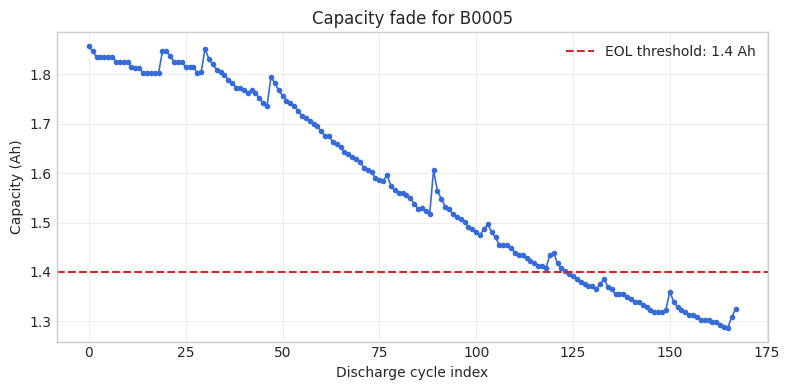

In [9]:
EOL_CAPACITY_AH = 1.4

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(discharge_df["discharge_cycle_index"], discharge_df["capacity_ah"], marker=".", linewidth=1.2)
ax.axhline(EOL_CAPACITY_AH, color="#d62728", linestyle="--", label="EOL threshold: 1.4 Ah")
ax.set_title(f"Capacity fade for {sample_path.stem}")
ax.set_xlabel("Discharge cycle index")
ax.set_ylabel("Capacity (Ah)")
ax.legend()
plt.tight_layout()

below_eol = discharge_df[discharge_df["capacity_ah"] <= EOL_CAPACITY_AH]
if below_eol.empty:
    print(f"{sample_path.stem} does not cross {EOL_CAPACITY_AH} Ah in this file.")
else:
    eol_cycle = int(below_eol.iloc[0]["discharge_cycle_index"])
    print(f"First discharge cycle at or below {EOL_CAPACITY_AH} Ah: {eol_cycle}")

## One Discharge Operation

This plot shows the raw within-cycle signals that later preprocessing may summarize or resample.

Capacity: 1.8565 Ah
Samples: 197
Duration: 3690.23 s


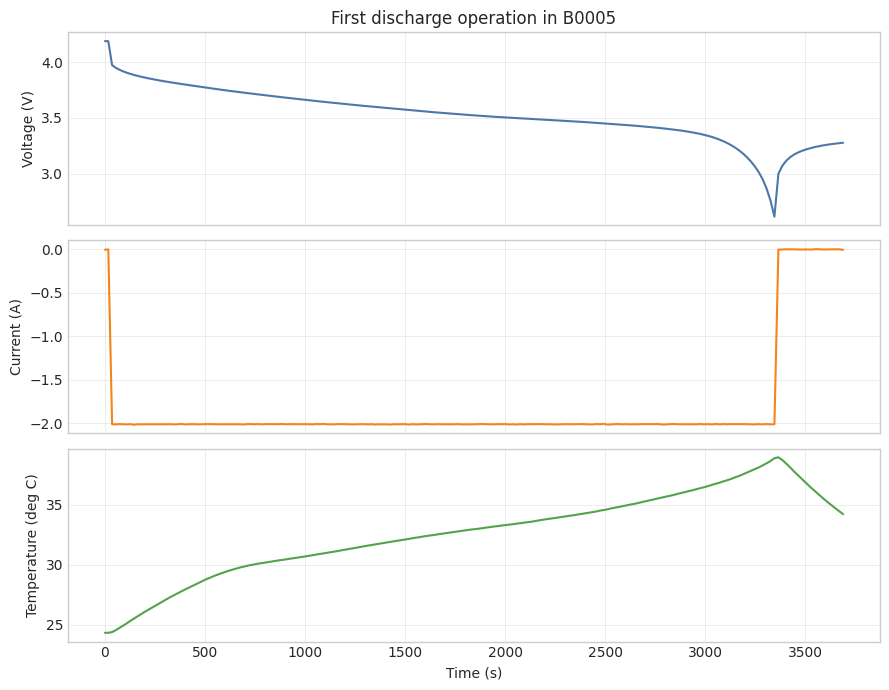

In [10]:
first_discharge = next(cycle for cycle in cycles if cycle.type == "discharge")
data = first_discharge.data

time = to_1d_array(data.Time)
voltage = to_1d_array(data.Voltage_measured)
current = to_1d_array(data.Current_measured)
temperature = to_1d_array(data.Temperature_measured)

print(f"Capacity: {float(np.asarray(data.Capacity).reshape(-1)[0]):.4f} Ah")
print(f"Samples: {len(time)}")
print(f"Duration: {time[-1] - time[0]:.2f} s")

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(time, voltage, color="#4c78a8")
axes[0].set_ylabel("Voltage (V)")
axes[0].set_title(f"First discharge operation in {sample_path.stem}")
axes[1].plot(time, current, color="#f58518")
axes[1].set_ylabel("Current (A)")
axes[2].plot(time, temperature, color="#54a24b")
axes[2].set_ylabel("Temperature (deg C)")
axes[2].set_xlabel("Time (s)")
plt.tight_layout()

## High-Level Inventory Across Batteries

This opens each `.mat` file and summarizes operation counts and capacity range.

In [11]:
inventory_rows = []

for path in mat_files:
    battery_obj = load_battery_mat(path)
    battery_cycles = np.atleast_1d(battery_obj.cycle)
    type_counts = pd.Series([cycle.type for cycle in battery_cycles]).value_counts().to_dict()
    discharges = [cycle for cycle in battery_cycles if cycle.type == "discharge"]
    capacities = np.asarray([optional_scalar(cycle.data, "Capacity") for cycle in discharges], dtype=float)

    inventory_rows.append({
        "battery_id": path.stem,
        "folder": path.parent.name,
        "total_entries": len(battery_cycles),
        "charge_entries": type_counts.get("charge", 0),
        "discharge_entries": type_counts.get("discharge", 0),
        "impedance_entries": type_counts.get("impedance", 0),
        "first_capacity_ah": np.nan if capacities.size == 0 else capacities[0],
        "last_capacity_ah": np.nan if capacities.size == 0 else capacities[-1],
        "min_capacity_ah": np.nan if capacities.size == 0 else np.nanmin(capacities),
        "crosses_1_4ah": bool(np.any(capacities <= EOL_CAPACITY_AH)),
    })

inventory_df = pd.DataFrame(inventory_rows)
inventory_df.sort_values(["folder", "battery_id"]).reset_index(drop=True)

,battery_id,folder,total_entries,charge_entries,discharge_entries,impedance_entries,first_capacity_ah,last_capacity_ah,min_capacity_ah,crosses_1_4ah
0,B0005,1. BatteryAgingARC-FY08Q4,616,170,168,278,1.856487,1.325079,1.287453,True
1,B0006,1. BatteryAgingARC-FY08Q4,616,170,168,278,2.035338,1.185675,1.153818,True
2,B0007,1. BatteryAgingARC-FY08Q4,616,170,168,278,1.891052,1.432455,1.400455,False
3,B0018,1. BatteryAgingARC-FY08Q4,319,134,132,53,1.855005,1.341051,1.341051,True
4,B0025,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.847011,1.767789,1.767789,False
5,B0026,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.813250,1.768754,1.386337,True
6,B0027,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.823308,1.770093,1.770093,False
7,B0028,2. BatteryAgingARC_25_26_27_28_P1,80,31,28,21,1.804685,1.717234,1.717234,False
8,B0025,3. BatteryAgingARC_25-44,80,31,28,21,1.847011,1.767789,1.767789,False
9,B0026,3. BatteryAgingARC_25-44,80,31,28,21,1.813250,1.768754,1.386337,True
